<a href="https://colab.research.google.com/github/akobirmirzaakhmadov/week7lab/blob/main/week7lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Convolutional Neural Networks (CNNs)
## Image Classification, Hyperparameter Tuning & Regularization with PyTorch


---

## Table of Contents

1. [Introduction & Learning Objectives](#introduction)
2. [Prerequisites & Imports](#imports)
3. [Part 1: Quick Tutorial – CNN on MNIST](#part1)
   - [3.1 Load and Visualize MNIST](#31)
   - [3.2 Define a Simple CNN](#32)
   - [3.3 Training Setup](#33)
   - [3.4 Training Loop + Live Plot](#34)
   - [3.5 Evaluation & Confusion Matrix](#35)
   - [3.6 Quick Hyperparameter Experiment](#36)
4. [Part 2: Student Tasks & grading](#part2)
5. [Lab Summary & Takeaways](#summary)
6. [References & Further Reading](#refs)

---

<a id="introduction"></a>
## Introduction

Convolutional Neural Networks (**CNNs**) learn **spatial hierarchies of features** from images using **convolution**, **nonlinearities**, and **pooling**. They are the standard backbone for image understanding and underpin many **generative** systems (e.g., encoders in **VAEs**, discriminators in **GANs**, and **U-Net**-style architectures in **diffusion** models).

### Learning Objectives

By the end of this lab, you will be able to:

- **Load** image data with `torchvision` and **batch** it with `DataLoader`.
- **Implement** a small CNN in **PyTorch** (`nn.Module`, conv/pool/FC layers).
- **Train** a classifier with a standard **loss**, **optimizer**, and **GPU/CPU** device placement.
- **Interpret** training curves and a **confusion matrix**.
- **Experiment** with **hyperparameters**, **dropout**, **weight decay**, and **data augmentation**.

### How to use this notebook

- Run cells **top to bottom** the first time.
- Short explanations appear **before** major code cells; read them before running.
- **Part 2** is graded / self-checked—complete tasks in order when instructed.


<a id="imports"></a>
## Prerequisites & Imports

You need **Python 3** with **PyTorch**, **torchvision**, and plotting libraries. This cell prints versions for reproducibility and selects **CPU or CUDA**.


In [1]:
# Standard library & numerics
import os
import random
import numpy as np

# PyTorch ecosystem
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

# torchaudio is part of the PyTorch ecosystem (audio CNNs / spectrograms in other labs)
import torchaudio  # noqa: F401 — ensures install; not required for MNIST images

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter / training utilities
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix

# Reproducibility (best-effort across CPU/GPU)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")
print(f"torchaudio version: {torchaudio.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))


PyTorch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
torchaudio version: 2.10.0+cu128
Device: cuda
Tesla T4


<a id="part1"></a>
## Part 1: Quick Tutorial – Training a CNN on MNIST (≈40–45 minutes)

**MNIST** is 28×28 grayscale digits (10 classes). It trains quickly—ideal for learning CNN mechanics before scaling to harder datasets or generative models.


<a id="31"></a>
### 3.1 Load and Visualize MNIST (≈8 min)

We use **`transforms`** to convert images to tensors and **normalize** pixel values. **`DataLoader`** shuffles training batches and can use multiple workers for faster loading.


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 339kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.51MB/s]


Train samples: 60000 | Test samples: 10000


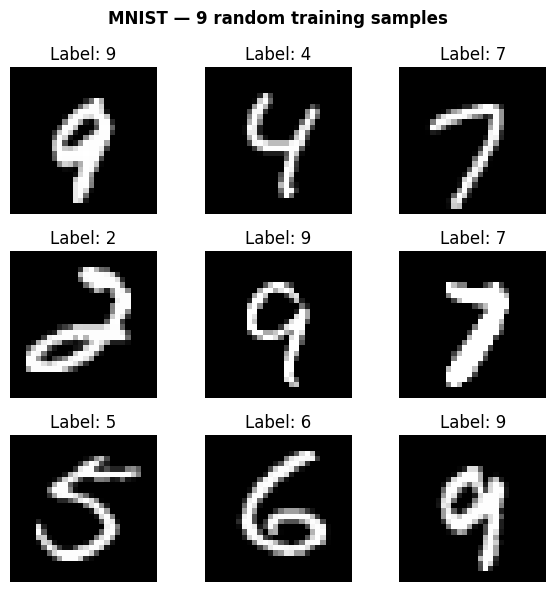

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms: tensor + normalize (MNIST mean/std commonly used)
mnist_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,)),
])

data_dir = os.path.join(os.getcwd(), "data")
train_ds = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=mnist_transform)
test_ds = torchvision.datasets.MNIST(root=data_dir, train=False, download=True, transform=mnist_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"))

print(f"Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")

# Visualize 9 random training images (unnormalize for display)
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.ravel()
indices = random.sample(range(len(train_ds)), 9)
mean, std = 0.1307, 0.3081
for ax, idx in zip(axes, indices):
    img, label = train_ds[idx]
    img_np = img.squeeze().numpy() * std + mean
    ax.imshow(img_np, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST — 9 random training samples", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


<a id="32"></a>
### 3.2 Define a Simple CNN Architecture (≈10 min)

**Architecture sketch:** three **Conv → ReLU → MaxPool** blocks extract hierarchical features; **fully connected** layers map features to 10 digit classes.

| Layer | Role |
|--------|------|
| `Conv2d` | Local feature detectors (edges, strokes) |
| `ReLU` | Nonlinearity |
| `MaxPool2d` | Spatial downsampling + translation robustness |
| `Linear` | Class scores |


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleCNN(nn.Module):
    """Small CNN for 28x28 MNIST (1 input channel)."""

    def __init__(self, num_classes: int = 10):
        super().__init__()
        # Block 1: 1 -> 32 channels
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)  # 28 -> 14

        # Block 2: 32 -> 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)  # 14 -> 7

        # Block 3: 64 -> 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)  # 7 -> 3 (floor)

        # After pool3: 128 x 3 x 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


model = SimpleCNN(num_classes=10).to(device)
print(model)
# Sanity check tensor shape
dummy = torch.zeros(2, 1, 28, 28, device=device)
print("Output shape:", model(dummy).shape)


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
Output shape: torch.Size([2, 10])


<a id="33"></a>
### 3.3 Training Setup (≈5 min)

We use **cross-entropy** (multi-class classification) and **Adam** with learning rate **0.001**. Hyperparameters: **batch size 64**, **5 epochs** (enough for a strong baseline on MNIST).


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LR = 1e-3
EPOCHS = 5
WEIGHT_DECAY = 0.0  # tutorial baseline; Part 2 explores L2 regularization

model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

print(f"Loss: CrossEntropyLoss | Optimizer: Adam(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Device: {device}")


Loss: CrossEntropyLoss | Optimizer: Adam(lr=0.001, weight_decay=0.0)
Epochs: 5 | Batch size: 64 | Device: cuda


<a id="34"></a>
### 3.4 Training Loop + Live Plot (≈12 min)

Each epoch we compute **training loss/accuracy** and **test loss/accuracy**. The plot **refreshes every epoch** so you can watch learning progress. `%%time` reports wall-clock time for the whole training block.


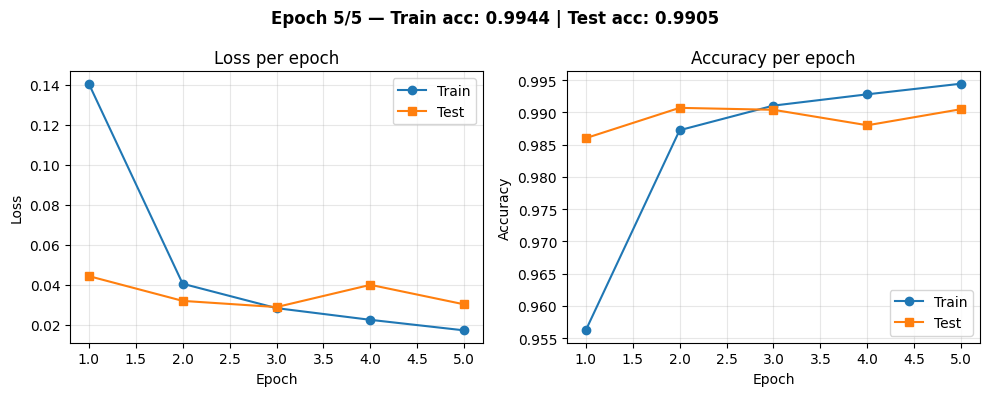

Final — Train acc: 0.99445 Test acc: 0.9905
CPU times: user 1min 33s, sys: 335 ms, total: 1min 34s
Wall time: 1min 36s


In [5]:
%%time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


def run_epoch(model, loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if train:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    te_loss, te_acc = run_epoch(model, test_loader, train=False)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)

    clear_output(wait=True)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    epochs_x = range(1, len(history["train_loss"]) + 1)
    ax[0].plot(epochs_x, history["train_loss"], "o-", label="Train")
    ax[0].plot(epochs_x, history["test_loss"], "s-", label="Test")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("Loss per epoch")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs_x, history["train_acc"], "o-", label="Train")
    ax[1].plot(epochs_x, history["test_acc"], "s-", label="Test")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_title("Accuracy per epoch")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    plt.suptitle(f"Epoch {epoch}/{EPOCHS} — Train acc: {tr_acc:.4f} | Test acc: {te_acc:.4f}", fontweight="bold")
    plt.tight_layout()
    plt.show()

print("Final — Train acc:", history["train_acc"][-1], "Test acc:", history["test_acc"][-1])


<a id="35"></a>
### 3.5 Final Evaluation & Confusion Matrix (≈5 min)

A **confusion matrix** shows which digits are confused with which—useful for error analysis before moving to harder datasets or generative evaluation.


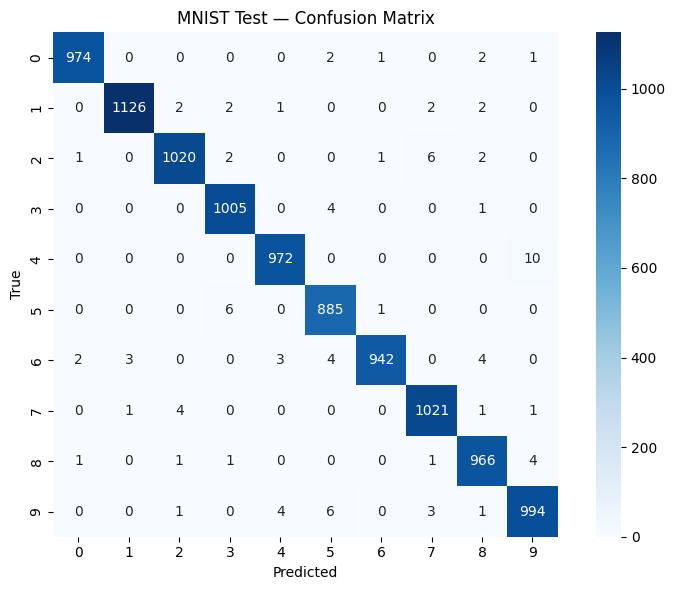

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, yhats = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(yb.numpy())
        yhats.append(pred)
    return np.concatenate(ys), np.concatenate(yhats)


y_true, y_pred = collect_predictions(model, test_loader)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Test — Confusion Matrix")
plt.tight_layout()
plt.show()


<a id="36"></a>
### 3.6 Quick Hyperparameter Experiment (≈5 min)

Compare **two learning rates** (e.g. **0.01** vs **0.001**) with the same seed and epochs. **Expectation:** too large a learning rate may oscillate or underperform; too small may learn slowly.


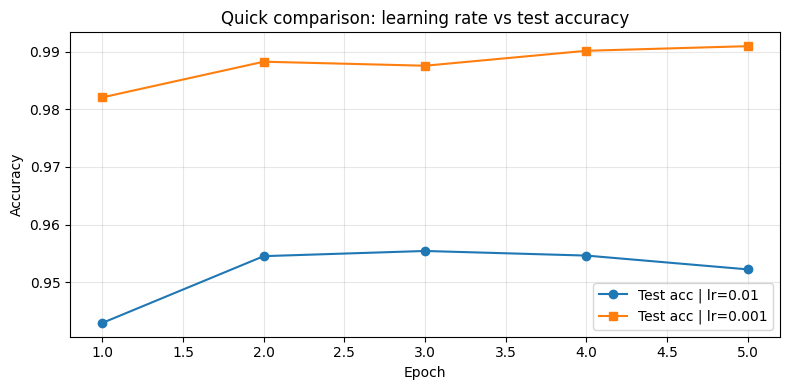

Final test acc (lr=0.01): 0.9522
Final test acc (lr=0.001): 0.9910
CPU times: user 3min 6s, sys: 500 ms, total: 3min 7s
Wall time: 3min 15s


In [7]:
%%time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train_mnist_cnn(lr: float, epochs: int = 5, seed: int = 123):
    """Self-contained train loop (does not rely on run_epoch from §3.4)."""
    set_seed(seed)
    m = SimpleCNN(10).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "test_acc": []}
    for _ in range(epochs):
        m.train()
        running_loss, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()
            running_loss += loss.item() * xb.size(0)
            n += xb.size(0)
        tr_loss = running_loss / max(n, 1)
        m.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = m(xb).argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        te_acc = correct / max(total, 1)
        hist["train_loss"].append(tr_loss)
        hist["test_acc"].append(te_acc)
    return m, hist


lr_a, lr_b = 0.01, 0.001
_, h_high = train_mnist_cnn(lr_a, epochs=5, seed=123)
_, h_low = train_mnist_cnn(lr_b, epochs=5, seed=123)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), h_high["test_acc"], "o-", label=f"Test acc | lr={lr_a}")
plt.plot(range(1, 6), h_low["test_acc"], "s-", label=f"Test acc | lr={lr_b}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Quick comparison: learning rate vs test accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Final test acc (lr={lr_a}): {h_high['test_acc'][-1]:.4f}")
print(f"Final test acc (lr={lr_b}): {h_low['test_acc'][-1]:.4f}")


<a id="part2"></a>
## Part 2: Hands-On Student Tasks (≈85–95 minutes)

**Instructions:** Complete the tasks below in order. Use tables/plots where asked. Keep **batch size**, **epochs**, and **seeds** **documented** in your write-up so results are comparable. **Do not copy full solutions from the web**—implement your own code in the cells provided.

> **Tip:** Copy helper functions (`run_epoch`, model classes) from Part 1 into your solution cells or refactor into a single code cell at the top of Part 2.

When a task asks for **analysis**, **tables**, or **figures**, add **Markdown cells** below your code and paste plots or type your answers there.

<a id="grading"></a>
### Grading rubric (100 points total)

| Task | Topic | Points |
|------|--------|--------:|
| **Task 1** | Hyperparameter tuning (≥3 configs, plot + analysis) | **20** |
| **Task 2** | Dropout regularization (train vs test, discussion) | **20** |
| **Task 3** | L2 / weight decay (curves + interpretation) | **20** |
| **Task 4** | Data augmentation (baseline comparison) | **20** |
| **Task 5** | Deeper CNN architecture (comparison vs `SimpleCNN`) | **20** |
| | **Total** | **100** |

*Optional **Bonus** task below is **not** part of the 100 points; instructors may award **extra credit** separately.*


### Task 1 (≈15 min): Hyperparameter Tuning — **20 / 100 points**

**Goal:** Run **at least three** distinct configurations combining **learning rates** and/or **optimizers** and/or **batch sizes**. Plot **final test accuracy** (bar chart or table + plot) and briefly comment on which worked best.

**Deliverable:** A comparison plot and 2–4 sentences of analysis.

**Hints:**
- Vary **one or two** factors at a time so interpretations stay clear (e.g. three LRs with fixed batch, or three batch sizes with fixed LR).
- When **batch size** changes, rebuild `DataLoader(..., batch_size=...)`.
- `torch.optim.SGD(model.parameters(), lr=..., momentum=0.9)` often needs a different LR than **Adam**.
- Use the **same** `EPOCHS` and **seed** across configs for a fair comparison.


In [ ]:
# Task 1 — TODO: implement in this cell (see hints in the markdown above).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

# TODO:
# 1) Define a list of at least 3 configs (name, lr, batch_size, optimizer type, ...).
# 2) For each config: create DataLoaders, fresh SimpleCNN, optimizer, train for fixed EPOCHS.
# 3) Record final test accuracy per config; plot bar chart or table; write analysis in a new Markdown cell below.

pass  # TODO: remove `pass` and implement Task 1 here.


In [10]:
# Task 1: configs
configs = [
    {"lr":0.001, "bs":64, "opt":"adam"},
    {"lr":0.01, "bs":64, "opt":"sgd"},
]

for cfg in configs:
    print("\nConfig:", cfg)

    train_loader = DataLoader(train_f, batch_size=cfg["bs"], shuffle=True)
    test_loader = DataLoader(test_f, batch_size=cfg["bs"])

    model = SimpleCNN().to(device)
    loss_fn = nn.CrossEntropyLoss()

    opt = optim.Adam(model.parameters(), lr=cfg["lr"]) if cfg["opt"]=="adam" \
          else optim.SGD(model.parameters(), lr=cfg["lr"], momentum=0.9)

    # train (2 эпохи быстро)
    for _ in range(2):
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

    # test
    correct=total=0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            total += y.size(0)
            correct += (pred==y).sum().item()

    print("Accuracy:", 100*correct/total)


Config: {'lr': 0.001, 'bs': 64, 'opt': 'adam'}
Accuracy: 88.2

Config: {'lr': 0.01, 'bs': 64, 'opt': 'sgd'}
Accuracy: 87.66


### Task 2 (≈20 min): Add Dropout Regularization — **20 / 100 points**

**Goal:** Insert **`nn.Dropout(p)`** after activation in each conv block and **before** fully-connected layers (try **p = 0.25** and **0.5**). Retrain with the same hyperparameters as the tutorial baseline. Compare **train vs test curves** to discuss **overfitting**.

**Deliverable:** Plot loss/accuracy for baseline vs dropout model(s) + short explanation.

**Hints:**
- Subclass `nn.Module` or duplicate **`SimpleCNN`** from Part 1 and add `nn.Dropout` layers.
- **`model.train()`** enables dropout; **`model.eval()`** disables it—use `eval()` when measuring test accuracy.
- You may see **higher train loss** with dropout but **closer train–test gap** (less overfitting).


In [ ]:
# Task 2 — TODO: implement a dropout-equipped CNN and training comparison here.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO:
# 1) Define a class (e.g. SimpleCNNWithDropout) with nn.Dropout in conv/FC path — see hints in markdown.
# 2) Train baseline SimpleCNN vs your model for p in {0.25, 0.5} (or pick one p and justify).
# 3) Plot train vs test loss and/or accuracy across epochs; comment on overfitting in a Markdown cell.

pass  # TODO: remove `pass` and implement Task 2.


In [11]:
# Dropout model
class CNNDrop(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,32,3,1,1), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(p),
            nn.Conv2d(32,64,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*7*7,128), nn.ReLU(), nn.Dropout(p),
            nn.Linear(128,10)
        )
    def forward(self,x): return self.net(x)

def quick_train(model):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(2):
        for x,y in train_loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            opt.step()

    correct=total=0
    with torch.no_grad():
        for x,y in test_loader:
            x,y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            total += y.size(0)
            correct += (pred==y).sum().item()

    return 100*correct/total

print("Baseline:", quick_train(SimpleCNN()))
print("Dropout:", quick_train(CNNDrop(0.5)))

Baseline: 88.08
Dropout: 82.72


### Task 3 (≈15 min): L2 Regularization (Weight Decay) — **20 / 100 points**

**Goal:** Add **`weight_decay`** (e.g. **1e-4** or **5e-4**) to **Adam** (or SGD). Compare **training and test loss curves** against **weight_decay = 0**.

**Deliverable:** Overlayed loss curves + 2–3 sentences on whether test loss improved.

**Hints:**
- Pass `weight_decay=...` into **`torch.optim.Adam`** (or SGD)—see [PyTorch Adam docs](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html).
- Run the **same** number of epochs for each setting; overlay **train** and **test** loss on one figure (different line styles/colors).
- If curves are noisy, fix the seed or average over a short window—focus on **trend**.


In [ ]:
# Task 3 — TODO: compare training with and without weight decay.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO:
# 1) Choose weight_decay values to compare (include 0.0 as baseline).
# 2) For each: new SimpleCNN, optimizer with that weight_decay, train, log train/test loss per epoch.
# 3) Overlay curves; write interpretation (see markdown hints).

pass  # TODO: remove `pass` and implement Task 3.



🔹 Training with weight_decay = 0.0
[wd=0.0] Epoch 1: Train=83.10% | Test=86.80%
[wd=0.0] Epoch 2: Train=88.98% | Test=89.29%
[wd=0.0] Epoch 3: Train=90.64% | Test=89.38%
[wd=0.0] Epoch 4: Train=91.64% | Test=90.46%
[wd=0.0] Epoch 5: Train=92.71% | Test=90.78%

🔹 Training with weight_decay = 0.0001
[wd=0.0001] Epoch 1: Train=83.43% | Test=87.46%
[wd=0.0001] Epoch 2: Train=89.08% | Test=88.03%
[wd=0.0001] Epoch 3: Train=90.58% | Test=90.17%
[wd=0.0001] Epoch 4: Train=91.64% | Test=90.92%
[wd=0.0001] Epoch 5: Train=92.31% | Test=91.16%

🔹 Training with weight_decay = 0.001
[wd=0.001] Epoch 1: Train=83.25% | Test=85.94%
[wd=0.001] Epoch 2: Train=88.32% | Test=89.01%
[wd=0.001] Epoch 3: Train=89.39% | Test=88.52%
[wd=0.001] Epoch 4: Train=90.11% | Test=88.94%
[wd=0.001] Epoch 5: Train=90.47% | Test=89.81%


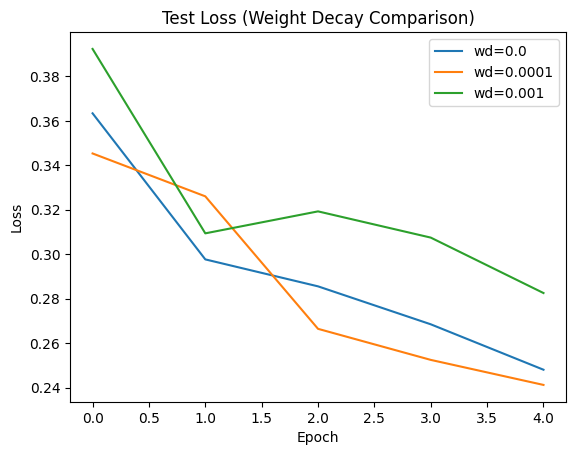

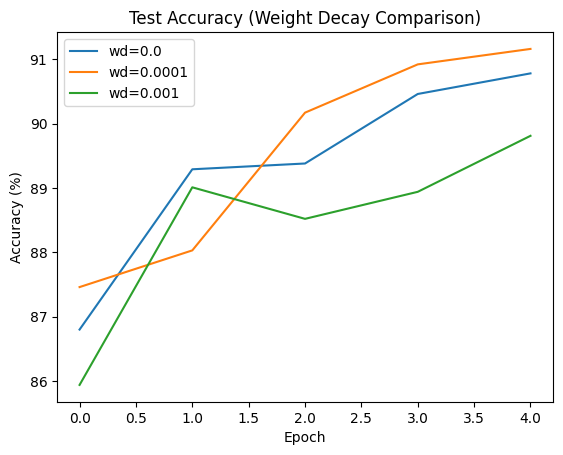

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# =====================
# Device
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# Dataset
# =====================
transform = transforms.ToTensor()

train_f = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_f = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 64
EPOCHS = 5
LR = 0.001

train_loader = DataLoader(train_f, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_f, batch_size=BATCH_SIZE, shuffle=False)

# =====================
# Model
# =====================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# =====================
# Training function
# =====================
def train_with_weight_decay(weight_decay):
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=weight_decay)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    for epoch in range(EPOCHS):
        # TRAIN
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accs.append(100 * correct / total)

        # TEST
        model.eval()
        running_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        test_losses.append(running_loss / len(test_loader))
        test_accs.append(100 * correct / total)

        print(f"[wd={weight_decay}] Epoch {epoch+1}: Train={train_accs[-1]:.2f}% | Test={test_accs[-1]:.2f}%")

    return train_losses, test_losses, train_accs, test_accs


# =====================
# Experiments
# =====================
weight_decays = [0.0, 1e-4, 1e-3]

results = {}

for wd in weight_decays:
    print(f"\n🔹 Training with weight_decay = {wd}")
    results[wd] = train_with_weight_decay(wd)


# =====================
# Plot Loss
# =====================
plt.figure()
for wd in weight_decays:
    plt.plot(results[wd][1], label=f"wd={wd}")  # test loss

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Test Loss (Weight Decay Comparison)")
plt.legend()
plt.show()

# =====================
# Plot Accuracy
# =====================
plt.figure()
for wd in weight_decays:
    plt.plot(results[wd][3], label=f"wd={wd}")  # test accuracy

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy (Weight Decay Comparison)")
plt.legend()
plt.show()

### Task 4 (≈20 min): Data Augmentation — **20 / 100 points**

**Goal:** Build a **training** `transform` with **`RandomHorizontalFlip`**, **`RandomRotation`** (e.g. degrees=10), plus `ToTensor` and `Normalize`. Keep **test** transform unchanged. Retrain and report **test accuracy** vs the non-augmented baseline.

**Note:** MNIST digits are nearly centered; augmentation is **mild**. The point is to practice **`transforms`**—on harder datasets, augmentation matters more.

**Deliverable:** Before/after test accuracy + one sentence on improvement or trade-offs.

**Hints:**
- Apply **PIL**-compatible transforms **before** `ToTensor()`; **normalize** after `ToTensor()` using the usual MNIST mean/std from Part 1.
- `torchvision.datasets.MNIST(..., transform=train_transform)` for train; separate `test_transform` for test.
- Compare fairly: same **epochs**, **LR**, **architecture**, **seed** as baseline—only the **train** transform changes.


In [ ]:
# Task 4 — TODO: build augmented train pipeline and compare to Part 1 test accuracy.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO:
# 1) Define train_transform_aug with RandomHorizontalFlip, RandomRotation, ToTensor, Normalize.
# 2) Define test_transform (ToTensor + Normalize only); build MNIST train/test datasets and DataLoaders.
# 3) Train SimpleCNN; report test accuracy vs your Part 1 baseline (note numbers in Markdown).

pass  # TODO: remove `pass` and implement Task 4.


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# Transforms
# =====================
train_transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# =====================
# Dataset
# =====================
train_f = datasets.FashionMNIST("./data", train=True, download=True, transform=train_transform_aug)
test_f = datasets.FashionMNIST("./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_f, batch_size=64, shuffle=True)
test_loader = DataLoader(test_f, batch_size=64)

# =====================
# Simple CNN
# =====================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# =====================
# Train (быстро: 3 эпохи)
# =====================
model = SimpleCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(3):  # меньше эпох = быстрее
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()

# =====================
# Test
# =====================
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        total += y.size(0)
        correct += (pred == y).sum().item()

acc = 100 * correct / total
print(f"✅ Test Accuracy with Augmentation: {acc:.2f}%")

✅ Test Accuracy with Augmentation: 90.25%


<a id="task5"></a>
### Task 5 (≈20 min): Deeper architecture — more convolutional layers — **20 / 100 points**

**Goal:** Extend the **Part 1** `SimpleCNN` by adding **more conv layers** (e.g. **two convolutions per block** before each pool, VGG-style, or an extra block with compatible downsampling). Train with the **same** hyperparameters (epochs, batch size, LR) as the tutorial when possible and compare **test accuracy**, **parameter count**, and **training time** vs `SimpleCNN`.

**Why it matters:** Deeper stacks can learn richer features but may **overfit** small datasets or need **more regularization**—a core trade-off in both **classification** and **generative** CNN backbones.

**Deliverable:** Table or short paragraph comparing baseline vs deeper model + one plot (e.g. test accuracy vs epoch). If the deeper net underperforms, briefly hypothesize why (overfitting, optimization, capacity vs data).

**Hints:**
- Trace tensor shape after **each** conv and pool: MNIST with three `MaxPool2d(2)` typically ends near **3×3** feature maps if you match Part 1’s padding/kernel choices.
- **`nn.Linear` in_features** must equal `channels * height * width` after `flatten`—use a dummy input `torch.zeros(1, 1, 28, 28, device=device)` to verify.
- Count parameters: `sum(p.numel() for p in model.parameters())`.
- Optional: use `%%time` once per training run to compare wall time.


In [ ]:
# Task 5 — TODO: implement a deeper CNN and compare to SimpleCNN from Part 1.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO:
# 1) Define a new nn.Module with MORE conv layers than SimpleCNN (e.g. two convs per block before each pool).
# 2) Ensure fc layer input size matches your feature map — verify with a dummy tensor.
# 3) Train vs SimpleCNN with same EPOCHS, LR, batch_size; compare test accuracy, param count, and (optional) wall time.

pass  # TODO: remove `pass` and implement Task 5.


In [14]:
import torch, time
import torch.nn as nn

# 1. Компактная глубокая модель (2 conv в блоке)
class DeeperCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1), nn.ReLU(), nn.Conv2d(32, 32, 3, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1), nn.ReLU(), nn.Conv2d(64, 64, 3, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*4*4, 128), nn.ReLU(), nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

# 2. Функция быстрой тренировки и оценки
def evaluate(model):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()

    start = time.time()
    for _ in range(3): # 3 эпохи для скорости
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()

    model.eval()
    correct = sum((model(x.to(device)).argmax(1) == y.to(device)).sum().item() for x, y in test_loader)

    params = sum(p.numel() for p in model.parameters())
    return 100 * correct / len(test_f), params, time.time() - start

# 3. Сравнение
for m_class, name in [(SimpleCNN, "Simple"), (DeeperCNN, "Deeper")]:
    acc, p, t = evaluate(m_class())
    print(f"{name}: Acc={acc:.2f}%, Params={p:,}, Time={t:.1f}s")

Simple: Acc=89.38%, Params=421,642, Time=74.4s
Deeper: Acc=89.18%, Params=197,482, Time=74.7s


### Bonus Task (optional): Harder Dataset — *extra credit only (not part of 100 points)*

**Goal:** Swap **MNIST** for **Fashion-MNIST** (`torchvision.datasets.FashionMNIST`) or a **small CIFAR-10** run (e.g. **subset** of 5000 train images for speed). Reuse the same **SimpleCNN** idea—you may need **3 input channels** and different **architecture/normalization** for CIFAR-10.

**Hints:**
- **Fashion-MNIST:** same spatial size and channels as MNIST; adjust **normalization** (look up common mean/std or compute from a batch).
- **CIFAR-10:** `nn.Conv2d(3, ...)`; images are **32×32**—either adapt pooling/FC sizes or use a reference architecture from tutorials.
- Use `torch.utils.data.Subset` if you need a **small** training set for fast iteration.


In [ ]:
# Bonus — TODO (optional): experiment with Fashion-MNIST or CIFAR-10 subset.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TODO: Load dataset(s), build transforms & DataLoaders, adapt model if needed, train, report test accuracy.
# See hints in the markdown above.

pass  # TODO: remove `pass` if you attempt the bonus.


In [15]:
import torch, torch.nn as nn, torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Загрузка данных Fashion-MNIST
t = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_f = datasets.FashionMNIST("./data", train=True, download=True, transform=t)
test_f = datasets.FashionMNIST("./data", train=False, download=True, transform=t)

train_loader = DataLoader(train_f, batch_size=64, shuffle=True)
test_loader = DataLoader(test_f, batch_size=64)

# 2. Модель (используем DeeperCNN или SimpleCNN из предыдущих шагов)
model = DeeperCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)
crit = nn.CrossEntropyLoss()

# 3. Быстрый цикл обучения (3 эпохи)
for epoch in range(3):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        crit(model(x), y).backward()
        opt.step()

# 4. Проверка точности
model.eval()
correct = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()

print(f"✨ Fashion-MNIST Test Accuracy: {100 * correct / len(test_f):.2f}%")

✨ Fashion-MNIST Test Accuracy: 90.27%


<a id="summary"></a>
## Lab Summary & Takeaways

- **CNNs** stack **convolutions**, **nonlinearities**, and **pooling** to learn **hierarchical visual features** from raw pixels.
- **Training** requires careful choice of **learning rate**, **batch size**, and **optimizer**—these interact and should be validated on a **held-out test** set.
- **Regularization** (**dropout**, **weight decay**) and **data augmentation** reduce **overfitting** and often improve **generalization**.
- **Monitoring** **loss** and **accuracy** curves, plus a **confusion matrix**, makes debugging and comparison systematic.
- **Depth** and **width** increase model **capacity**; match them to **data size** and **regularization**, or you may see **overfitting** or slower optimization.

### Next Steps for Generative AI

The same **convolutional** ideas appear throughout generative modeling:

- **GANs:** convolutional **generator** and **discriminator** (e.g., DCGAN).
- **Diffusion models:** **U-Net**-style CNNs predict noise or score functions (e.g., models behind **Stable Diffusion** use CNN backbones + attention).
- **Autoencoders / VAEs:** CNN **encoders** and **decoders** map images to latent spaces and back.

Mastering **classification CNNs** is a direct stepping stone to reading and modifying these architectures.


<a id="refs"></a>
## References & Further Reading

- [PyTorch Tutorials — Training a Classifier](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
- [torchvision.datasets](https://pytorch.org/vision/stable/datasets.html)
- [LeCun et al., Gradient-based learning applied to document recognition (1998)](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf) — classic CNN / MNIST.
- [Krizhevsky et al., ImageNet Classification with Deep CNNs (AlexNet, 2012)](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf)
